In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(cowplot))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(RColorBrewer))
suppressPackageStartupMessages(library(ggplotify))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

tmp_order <- c('Start', 'Sendai', 'Delayed', 'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#9C4F43', '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')
names(clust_hexes) <- tmp_order

subclust_order <- c('Start_1', 'Start_2', 'Sendai_1', 'Sendai_2', 'Skin', 'Inflamed',
                    'Delayed_1', 'Delayed_2', 'Delayed_3', 'Fail1_1', 'Fail1_2', 'Fail1_3', 'Fail1_4',
                    'Inter1_1', 'Inter1_2', 'Inter1_3', 'Inter1_4', 'Inter1_5',
                    'Inter2_1', 'Inter2_2', 'Inter2_3', 'Inter2_4',
                    'Fail2_1', 'Fail2_2', 'Fail2_3', 'Fail2_4', 'Fail2_5', 'IPS_1', 'IPS_2', 'IPS_3')
subclust_hexes <- c('#BC687A', '#B96B6B', '#B56F5C', '#AF734B', '#AF7605', '#A57B00', '#988104', '#898600',
                    '#788A07', '#638E03', '#459202', '#21953D', '#049850', '#0A9965', '#009B77', '#049A89',
                    '#079999', '#0B98A8', '#0094B5', '#068FBF', '#2189C3', '#5F81BD', '#777BBF', '#8B75BF',
                    '#9D6EBD', '#AC67B8', '#B762B0', '#BF5FA5', '#C16097', '#C06489')
names(subclust_hexes) <- subclust_order

base_theme <- theme(
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### A: 10x RNA UMAP, subclusters

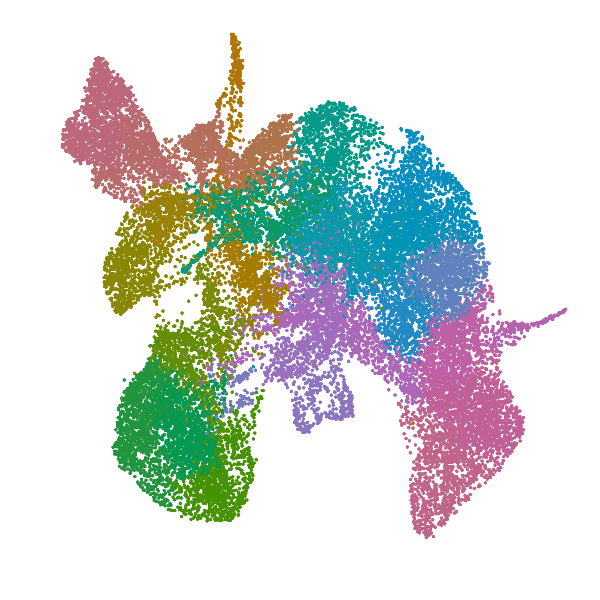

In [ ]:
multiome_rna_umap_path = paste0(projdir, '/csv/figure1/multiome_rna_umap.csv')
multiome_rna_umap = as.data.frame(fread(multiome_rna_umap_path, sep='\t'))
multiome_rna_umap$coarse_v7 <- factor(multiome_rna_umap$coarse_v7, levels=tmp_order)
multiome_rna_umap$clusters_v7 <- factor(multiome_rna_umap$clusters_v7, levels=subclust_order)

set.seed(1)
shuffled_multiome_rna_umap <- multiome_rna_umap[sample(nrow(multiome_rna_umap)), ]

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_multiome_rna_umap, aes(x = umap0, y = umap1, color = clusters_v7)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "", color = 'Clusters') +
  theme_bw() +
  base_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_manual(values = subclust_hexes)

### B: node tracing of the three branches

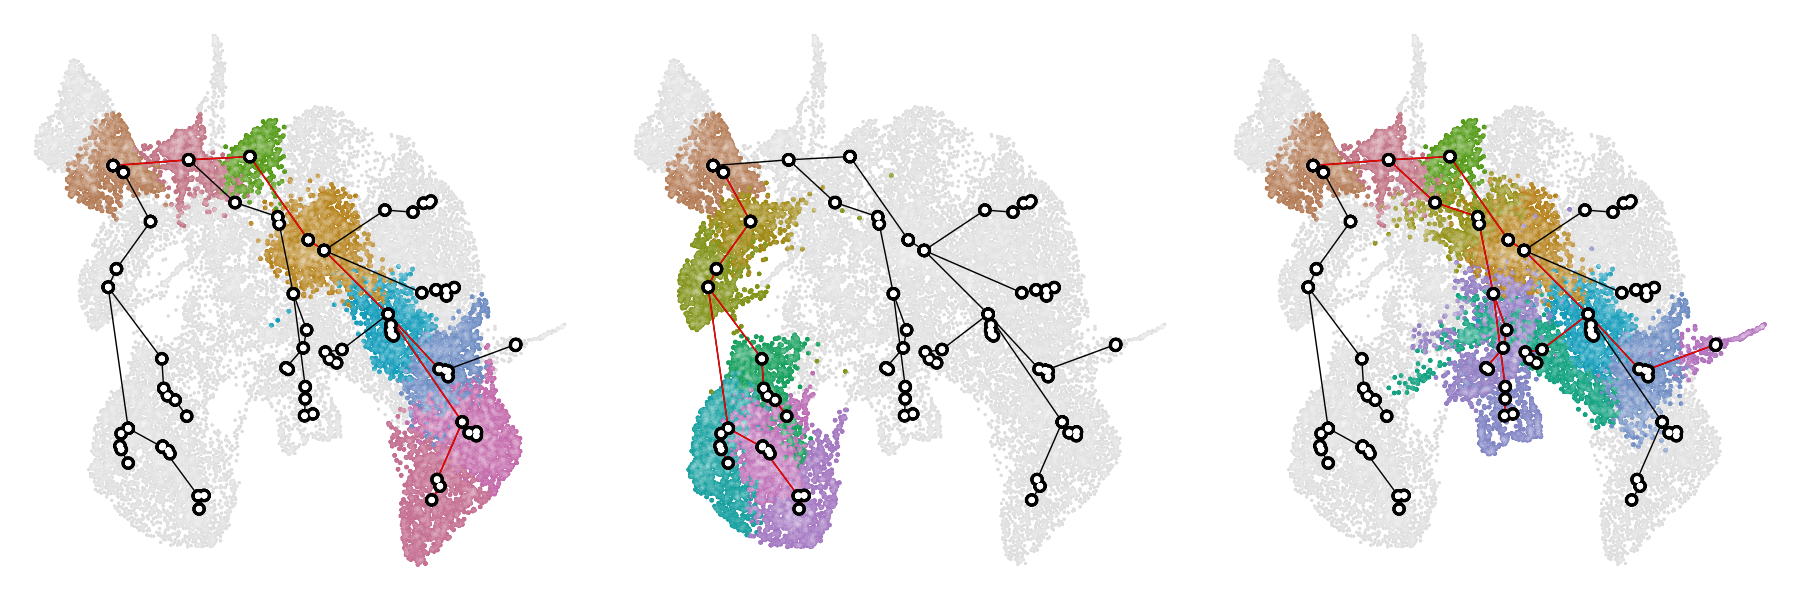

In [ ]:
rna_umap_path = paste0(projdir, '/csv/figure3/node_tracing_markers.csv')
rna_umap = read.csv(rna_umap_path, sep='\t')
rna_umap$NewGeneral <- factor(rna_umap$NewGeneral, levels=tmp_order)

rna_meta_path = paste0(projdir, '/csv/figure3/node_tracing_path.csv')
rna_meta = read.csv(rna_meta_path, sep='\t')

set.seed(1)
rna_umap <- rna_umap[sample(nrow(rna_umap)), ]

plot_node <- function(tmp_umap, tmp_meta, clust) {

  tmp.path.table <- tmp_meta %>%
    filter(Path == clust) %>%
    mutate(Node_Cluster = str_c(word(Node, 2, sep = "_"),
                                word(Node, 3, sep = "_"),
                                sep = "_"))

  highlight_clusters <- tmp.path.table$Node_Cluster
  umap_highlight <- tmp_umap %>% filter(Cluster %in% highlight_clusters)
  meta_highlight <- tmp_meta %>% filter(Path == clust)
  label_df <- tmp_umap %>% distinct(Cluster, .keep_all = TRUE) %>% filter(Cluster %in% highlight_clusters)

  ggplot(tmp_umap, aes(umap0, umap1)) +
    geom_point_rast(size = 0.1, color = 'grey85') +
    geom_point_rast(data = umap_highlight, aes(color = Cluster), size = 0.5) +
    geom_point_rast(color = "white", alpha = 0.05, size = 0.5) +
    geom_line(data = tmp_meta, aes(mean_umap0, mean_umap1, group = Group),
              linewidth = 0.3, inherit.aes = FALSE) +
    geom_line(data = meta_highlight, aes(mean_umap0, mean_umap1, group = Group2),
              color = "red", linewidth = 0.3, inherit.aes = FALSE) +
    geom_point_rast(data = tmp_meta, aes(mean_umap0, mean_umap1),
                    color = "black", size = 3, inherit.aes = FALSE) +
    geom_point_rast(data = tmp_meta, aes(mean_umap0, mean_umap1),
                    color = "white", size = 1, inherit.aes = FALSE) +
    labs(x = "", y = "", color = "") +
    theme_bw() +
    base_theme +
    theme(
      axis.text = element_blank(),
      axis.title = element_blank(),
      axis.line = element_blank(),
      axis.ticks = element_blank()
    ) +
    scale_color_manual(values = subclust_hexes)
}

node_clusts <- c('IPS', 'Fail1', 'Fail2')

plot_list <- list()

for (i in seq_along(node_clusts)) {
    tmp_clust = node_clusts[i]
    plot_list[[i]] = plot_node(rna_umap, rna_meta, tmp_clust)
}
w = 15
h = 5
options(repr.plot.width=w, repr.plot.height=h)

combined_plot <- plot_grid(plotlist = plot_list, ncol=3)
combined_plot

### C: fraction of each subcluster per donor

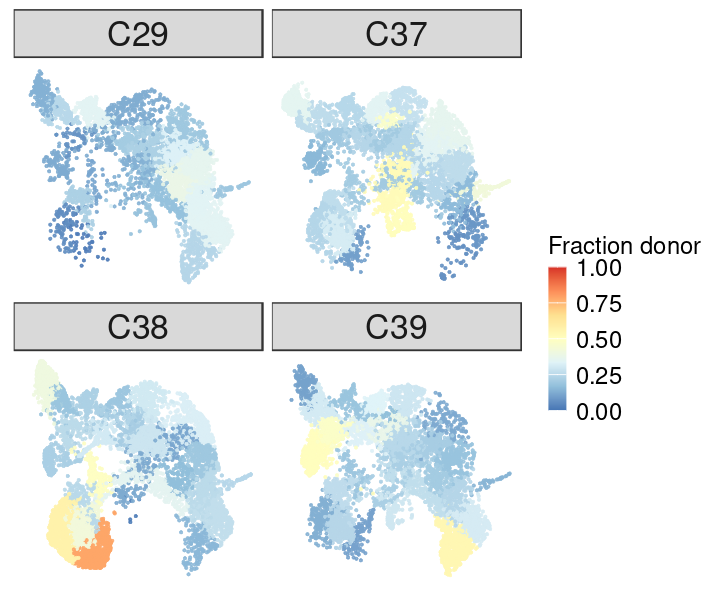

In [ ]:
tmp_path = paste0(projdir, '/csv/figure4/rna_umap_pct_donor_meta.csv')
rna_umap = read.csv(tmp_path, sep='\t')
set.seed(1)
shuffled_rna_umap <- rna_umap[sample(nrow(rna_umap)), ]

w = 6
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(shuffled_rna_umap, aes(x = umap0, y = umap1, color = percent_donor)) +
  geom_point_rast(alpha=0.8, size = 0.3) +
labs(x = "", y = "", color=NULL) +
  theme_bw() +
  facet_wrap(~donor) +
   base_theme +
   theme(
          axis.text = element_blank(),
          axis.title = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 14),
         legend.title = element_text(size=14),
         strip.text = element_text(size=20),
         legend.key.height = unit(0.5, 'cm')) +
        scale_color_distiller(palette = "RdYlBu", limits = c(0, 1), oob = scales::squish) +
        guides(color = guide_colorbar(title = 'Fraction donor', barwidth = 0.75, barheight = 6,
                                      ticks = TRUE))

### D: subcluster-specific DEG expression per branch

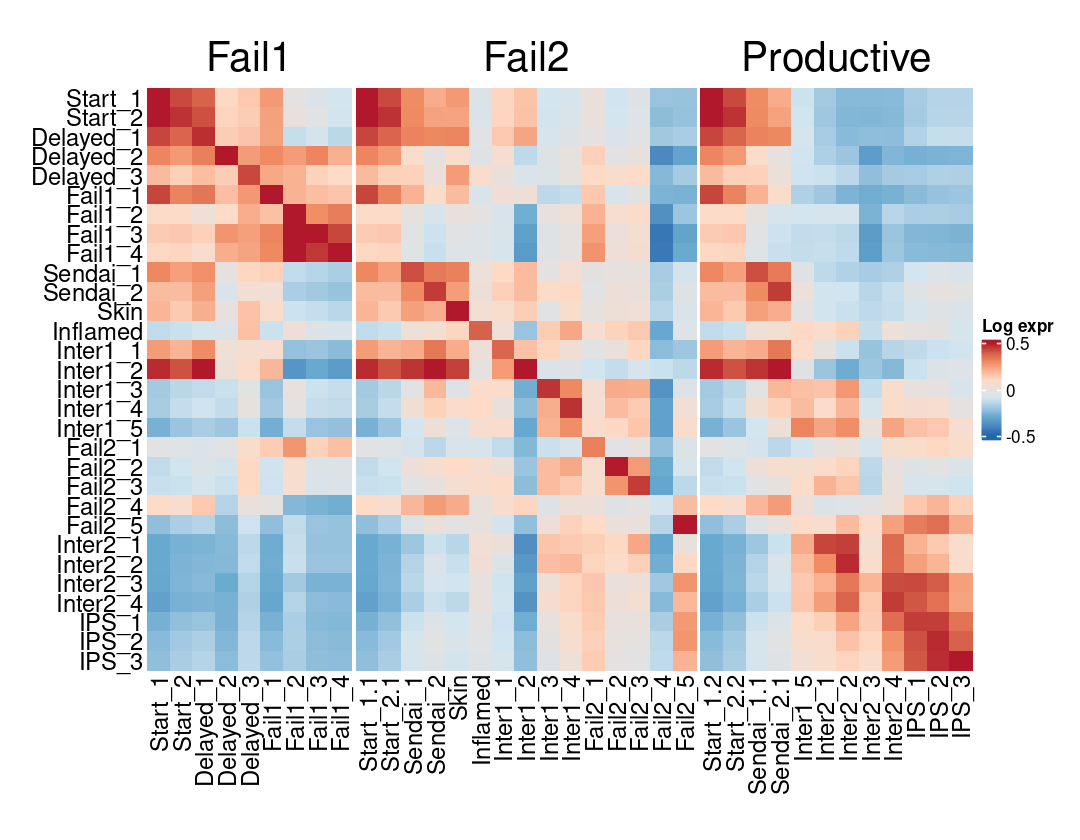

In [ ]:
subclust1_order <- c("Start_1","Start_2"  ,  "Delayed_1" , "Delayed_2", "Delayed_3" , "Fail1_1" ,
                    "Fail1_2" , "Fail1_3" ,  "Fail1_4"  ,  "Sendai_1" , "Sendai_2" ,  "Skin", "Inflamed" ,"Inter1_1",  "Inter1_2",
                    "Inter1_3" , "Inter1_4" ,   "Inter1_5" , "Fail2_1"  , "Fail2_2",   "Fail2_3",
                    "Fail2_4" , "Fail2_5", "Inter2_1", "Inter2_2",
                    "Inter2_3"   ,  "Inter2_4"  ,"IPS_1"   ,  "IPS_2"   ,  "IPS_3")

subclust2_order <- c("Start_1","Start_2"  ,  "Delayed_1" , "Delayed_2", "Delayed_3" , "Fail1_1" ,
                      "Fail1_2" , "Fail1_3" ,  "Fail1_4" ,
                      "Start_1","Start_2" ,"Sendai_1" , "Sendai_2" ,  "Skin", "Inflamed" ,"Inter1_1",  "Inter1_2",
                      "Inter1_3" , "Inter1_4", "Fail2_1"  , "Fail2_2",   "Fail2_3",
                      "Fail2_4" , "Fail2_5",
                      "Start_1","Start_2"  ,"Sendai_1" , "Sendai_2",   "Inter1_5" ,"Inter2_1", "Inter2_2",
                      "Inter2_3"   ,  "Inter2_4"  ,"IPS_1"   ,  "IPS_2"   ,  "IPS_3" )

tmp_path <- "/u/project/cluo/IGVF_Share/personaldirs/justin/YS3v7_Figs/TrajFig/2026-06-18_YS3v7_fig3_summary_figure_pieces/YS3v7.SummaryFig.DEGs_All.gene.exp_Cluster.3Path.Scaled.heatmap.tsv"
expr <- as.data.frame(fread(tmp_path))
rownames(expr) <- expr[,1]
expr <- expr[,-1]
expr <- expr[subclust1_order, subclust2_order]

col_split <- c(rep('Fail1', 9), rep('Fail2', 15), rep('Productive', 12))

w = 9
h = 7
options(repr.plot.width=w, repr.plot.height=h)

col_fun <- colorRamp2(seq(-0.5, 0.5, length.out = 6), rev(brewer.pal(6, "RdBu")))

ht <- Heatmap(
    expr,
    name = "Log expr",
    col = col_fun,
    column_split = col_split,
    row_names_side = "left",
    column_names_side = "bottom",
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    heatmap_width = unit(20, "cm"),
    heatmap_height = unit(16, "cm"),
    row_names_gp = gpar(fontsize = 14),
    column_names_gp = gpar(fontsize = 14),
    column_title_gp = gpar(fontsize = 24),
    column_names_rot = 90,
    column_title = '',
    row_title = '',
)
p <- as.ggplot(ht)
p

### E: fibroblast vs. pluripotent score per branch

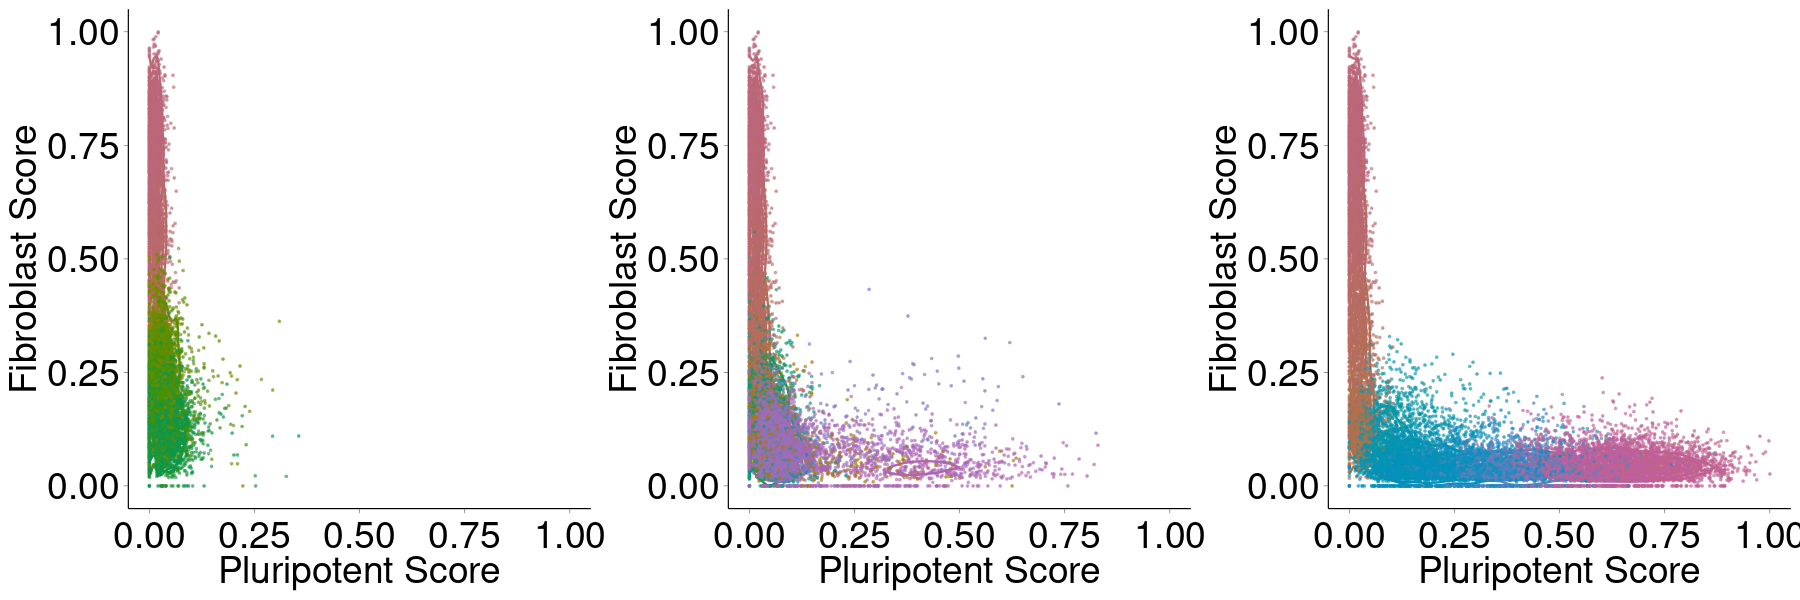

In [ ]:
tmp_path <- '/u/project/cluo/IGVF_Share/personaldirs/justin/YS3v7_Figs/TrajFig/2026-06-18_YS3v7_fig3_summary_figure_pieces/YS3v7.SummaryFig.Cluster.Trajectory_trend_and_scatter.Contour.tsv'
traj_score <- as.data.frame(fread(tmp_path))
traj_score$Cluster <- factor(traj_score$Cluster, levels=subclust1_order)

plot_contour <- function(tmp_df, path) {
    mask <- tmp_df$Cluster %in% path
    tmp_plot <- tmp_df[mask,]
    ggplot(tmp_plot) +
      geom_density_2d(aes(x = ES.Trend, y = Fibro.Trend, color = Cluster), alpha=1) +
      geom_point_rast(aes(x = ES.Trend, y = Fibro.Trend, color = Cluster), alpha=0.5, size=0.2)+
      labs(x = "Pluripotent Score", y = "Fibroblast Score") +
      theme_bw() +
      base_theme +
       theme(axis.text.x = element_text(size=22, angle=0, hjust=0.5, vjust=0.5, color='black'),
            axis.text.y = element_text(size=22, color='black'),
            axis.title.x = element_text(size=22, color='black'),
            axis.title.y = element_text(size=22, color='black'),
            axis.line = element_line(linewidth=0.25, color='black'),
             axis.ticks.x = element_line(linewidth=0.1),
             axis.ticks.y = element_line(linewidth=0.1),
             legend.position = 'none',
            plot.title = element_text(size = 20, hjust = 0.2)) +
        scale_color_manual(values = subclust_hexes) +
    coord_cartesian(xlim = c(0, 1), ylim = c(0, 1))
}

path_1 <-c("Start_1","Start_2"  ,  "Delayed_1" , "Delayed_2", "Delayed_3" , "Fail1_1" ,
           "Fail1_2" , "Fail1_3" ,  "Fail1_4")
path_2 <-c("Start_1","Start_2" ,"Sendai_1" , "Sendai_2" ,  "Skin", "Inflamed" ,"Inter1_1",  "Inter1_2",
           "Inter1_3" , "Inter1_4", "Fail2_1"  , "Fail2_2",   "Fail2_3",
           "Fail2_4" , "Fail2_5")
path_3 <-c("Start_1","Start_2"  ,"Sendai_1" , "Sendai_2",   "Inter1_5" ,"Inter2_1", "Inter2_2",
           "Inter2_3"   ,  "Inter2_4"  ,"IPS_1"   ,  "IPS_2"   ,  "IPS_3")
path_list <- list(path_1, path_2, path_3)
plot_list <- list()

for (i in seq_along(path_list)) {
    tmp_paths <- path_list[[i]]
    plot_list[[i]] <- plot_contour(traj_score, tmp_paths)
}

w = 15
h = 5
options(repr.plot.width=w, repr.plot.height=h)

p <- plot_grid(plotlist = plot_list, ncol=3)
p

### F: GO term expression in Start, Delayed, Fail1

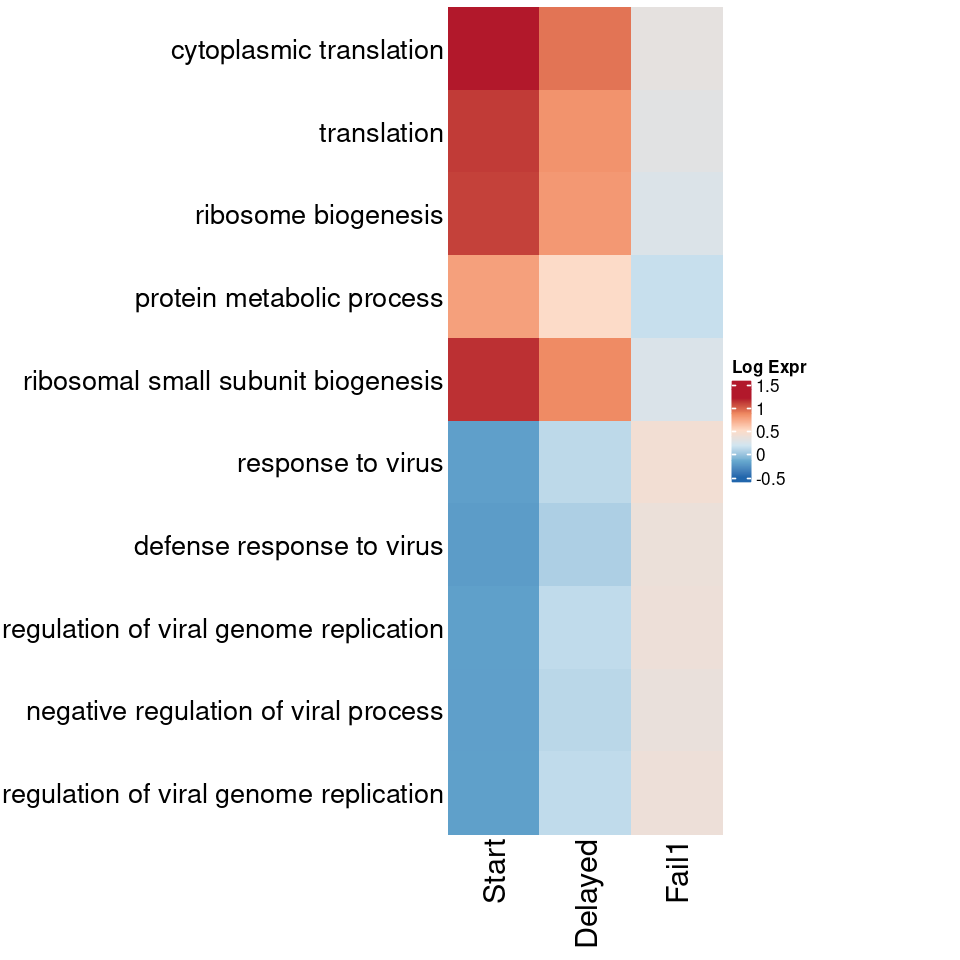

In [ ]:
gene_ontology_path = paste0(projdir, '/csv/figure3/coarse_gene_ontology.csv')
gene_ontology = as.data.frame(fread(gene_ontology_path))
gene_ontology = gene_ontology[,-1]
rownames(gene_ontology) <- gene_ontology$GO
gene_ontology = gene_ontology[,-ncol(gene_ontology)]

start_go <- gene_ontology[1:5,]
fail1_go <- gene_ontology[21:25,]
final_go <- rbind(start_go, fail1_go)

w = 8
h = 8
options(repr.plot.width=w, repr.plot.height=h)

col_fun <- colorRamp2(seq(-0.5, 1.2, length.out = 6), rev(brewer.pal(6, "RdBu")))

ht <- Heatmap(
    final_go,
    name = "Log Expr",
    col = col_fun,
    row_names_side = "left",
    column_names_side = "bottom",
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    heatmap_width = unit(12, "cm"),
    heatmap_height = unit(20, "cm"),
    row_names_gp = gpar(fontsize = 16),
    column_names_gp = gpar(fontsize = 18),
    column_title_gp = gpar(fontsize = 24),
    column_names_rot = 90,
    column_title = '',
    row_title = '',
)
p <- as.ggplot(ht)
p

In [ ]:
sessionInfo()

In [ ]:
Sys.time()